In [12]:
import pandas as pd

df = pd.read_csv("../data/processed/btc_1sec_core.csv")
df.head()

,system_time,midpoint,spread,buys,sells
0,2021-04-07 12:32:42.122161+01,56035.995,0.01,0.0,0.0
1,2021-04-07 12:32:43.122161+01,56035.995,0.01,0.0,0.0
2,2021-04-07 12:32:44.122161+01,56035.995,0.01,0.0,0.0
3,2021-04-07 12:32:45.122161+01,56035.995,0.01,0.0,0.0
4,2021-04-07 12:32:46.122161+01,56035.995,0.01,0.0,0.0


In [13]:
df['system_time'] = pd.to_datetime(df['system_time'])
df = df.set_index(df['system_time'])
df.head()

,system_time,midpoint,spread,buys,sells
system_time,,,,,
2021-04-07 12:32:42.122161+01:00,2021-04-07 12:32:42.122161+01:00,56035.995,0.01,0.0,0.0
2021-04-07 12:32:43.122161+01:00,2021-04-07 12:32:43.122161+01:00,56035.995,0.01,0.0,0.0
2021-04-07 12:32:44.122161+01:00,2021-04-07 12:32:44.122161+01:00,56035.995,0.01,0.0,0.0
2021-04-07 12:32:45.122161+01:00,2021-04-07 12:32:45.122161+01:00,56035.995,0.01,0.0,0.0
2021-04-07 12:32:46.122161+01:00,2021-04-07 12:32:46.122161+01:00,56035.995,0.01,0.0,0.0


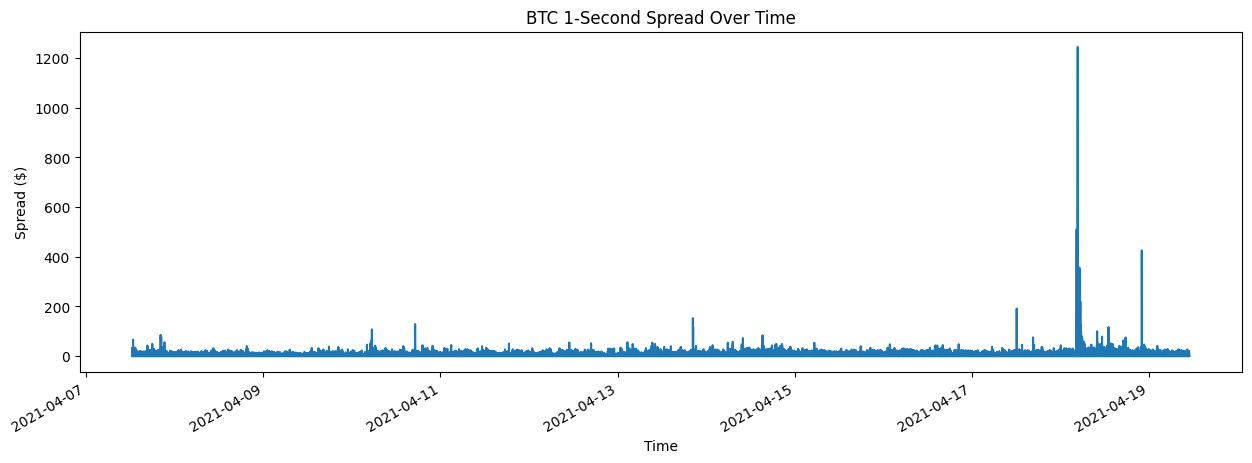

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
df['spread'].plot()
plt.title('BTC 1-Second Spread Over Time')
plt.ylabel('Spread ($)')
plt.xlabel('Time')
plt.show()



In [15]:
df['spread'].describe()

count    1.030728e+06
mean     1.314033e+00
std      4.713295e+00
min      1.000000e-02
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.245100e+03
Name: spread, dtype: float64

# Investigating the Spike in Spread

In [16]:
spike_time =df['spread'].idxmax()
spike_time

Timestamp('2021-04-18 04:40:23.377516+0100', tz='UTC+01:00')

### Pull a window of 5 minutes before and after

In [17]:
window = df.loc[spike_time - pd.Timedelta(minutes=5):
                spike_time + pd.Timedelta(minutes=5)]

window.head()

,system_time,midpoint,spread,buys,sells
system_time,,,,,
2021-04-18 04:35:23.377516+01:00,2021-04-18 04:35:23.377516+01:00,52500.005,0.01,92404.893337,537689.506760
2021-04-18 04:35:24.377516+01:00,2021-04-18 04:35:24.377516+01:00,52500.005,0.01,38214.815029,260119.888350
2021-04-18 04:35:25.377516+01:00,2021-04-18 04:35:25.377516+01:00,52395.835,14.63,33836.484809,525085.496499
2021-04-18 04:35:26.377516+01:00,2021-04-18 04:35:26.377516+01:00,52388.895,0.01,85736.093242,213465.010976
2021-04-18 04:35:27.377516+01:00,2021-04-18 04:35:27.377516+01:00,52387.895,0.01,30947.152530,103659.898166


#### Spread

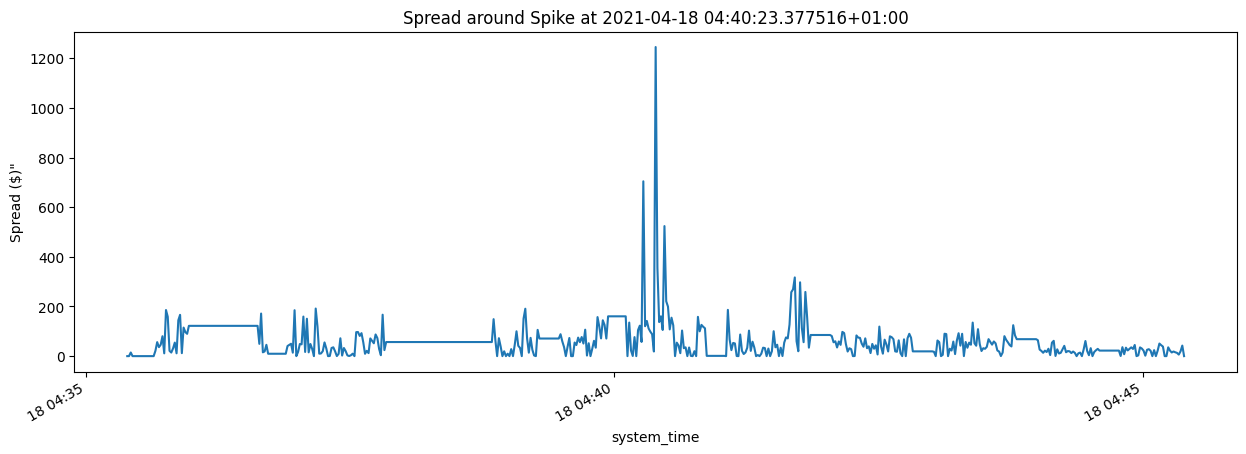

In [11]:
plt.figure(figsize=(15, 5))
window['spread'].plot()
plt.title(f'Spread around Spike at {spike_time}')
plt.ylabel('Spread ($)"')
plt.show()

#### Midpoint

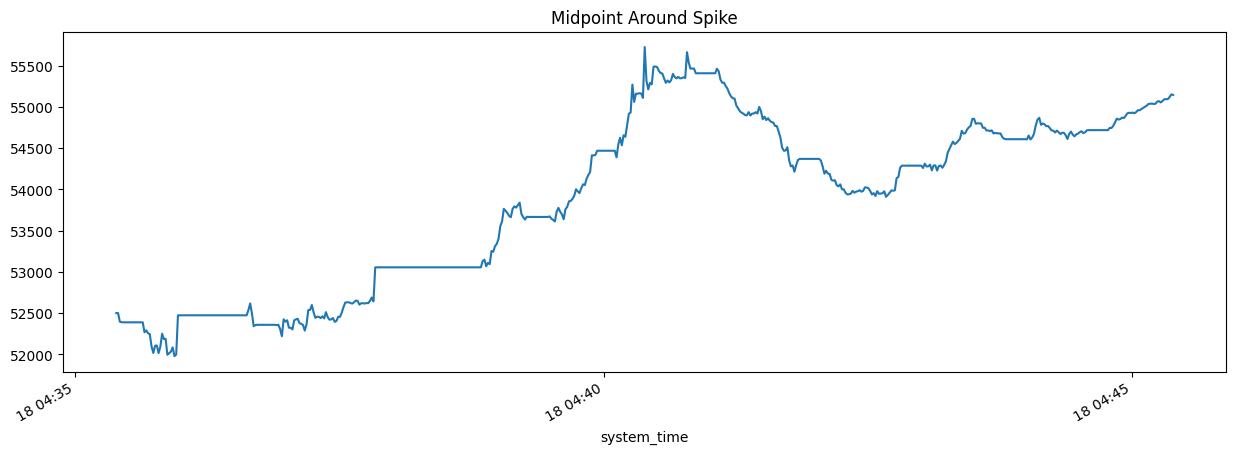

In [19]:
plt.figure(figsize=(15,5))
window['midpoint'].plot()
plt.title("Midpoint Around Spike")
plt.show()


#### Buys - Sells

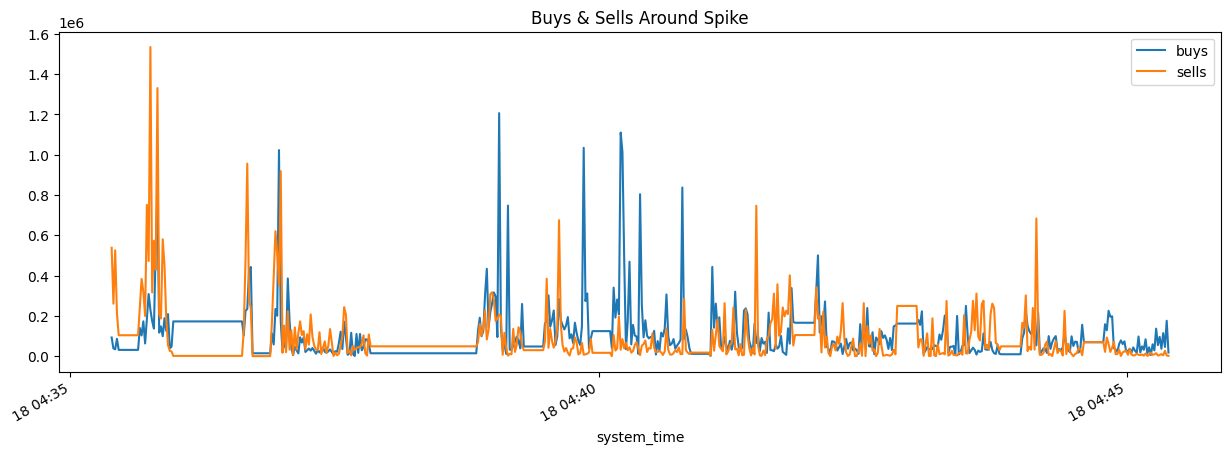

In [20]:
window[['buys', 'sells']].plot(figsize=(15, 5))
plt.title('Buys & Sells Around Spike')
plt.show()

#### Identified short-lived liquidity vacuum events in BTC 1-second limit-order-book data, characterized by extreme spread widening (> $1200), aggressive buy-side order flow, and sharp midpoint dislocations.